2025-05-20 17:46:36.721110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747763196.952460      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747763197.018344      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


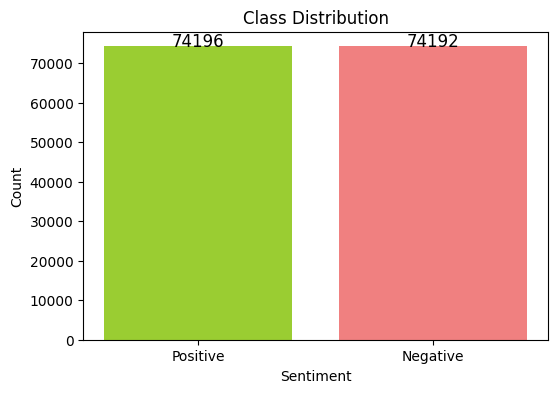

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


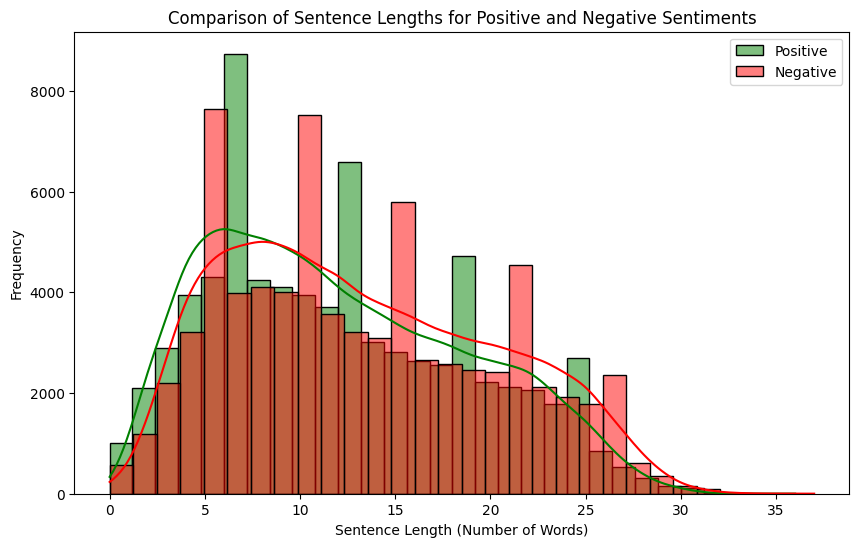

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2700: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 2 ========
Training...
  Batch 40 of 4638 - Loss: 0.3781
  Batch 80 of 4638 - Loss: 0.4835
  Batch 120 of 4638 - Loss: 0.4319
  Batch 160 of 4638 - Loss: 0.5005
  Batch 200 of 4638 - Loss: 0.7238
  Batch 240 of 4638 - Loss: 0.5321
  Batch 280 of 4638 - Loss: 0.5665
  Batch 320 of 4638 - Loss: 0.4549
  Batch 360 of 4638 - Loss: 0.5145
  Batch 400 of 4638 - Loss: 0.5696
  Batch 440 of 4638 - Loss: 0.4313
  Batch 480 of 4638 - Loss: 0.4669
  Batch 520 of 4638 - Loss: 0.3497
  Batch 560 of 4638 - Loss: 0.3505
  Batch 600 of 4638 - Loss: 0.3196
  Batch 640 of 4638 - Loss: 0.4959
  Batch 680 of 4638 - Loss: 0.2794
  Batch 720 of 4638 - Loss: 0.3590
  Batch 760 of 4638 - Loss: 0.5264
  Batch 800 of 4638 - Loss: 0.2591
  Batch 840 of 4638 - Loss: 0.4458
  Batch 880 of 4638 - Loss: 0.3442
  Batch 920 of 4638 - Loss: 0.4314
  Batch 960 of 4638 - Loss: 0.5142
  Batch 1000 of 4638 - Loss: 0.4424
  Batch 1040 of 4638 - Loss: 0.3475
  Batch 1080 of 4638 - Loss: 0.3391
  Batch 112

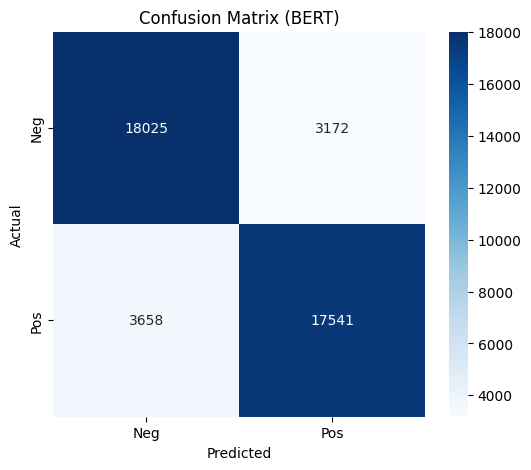

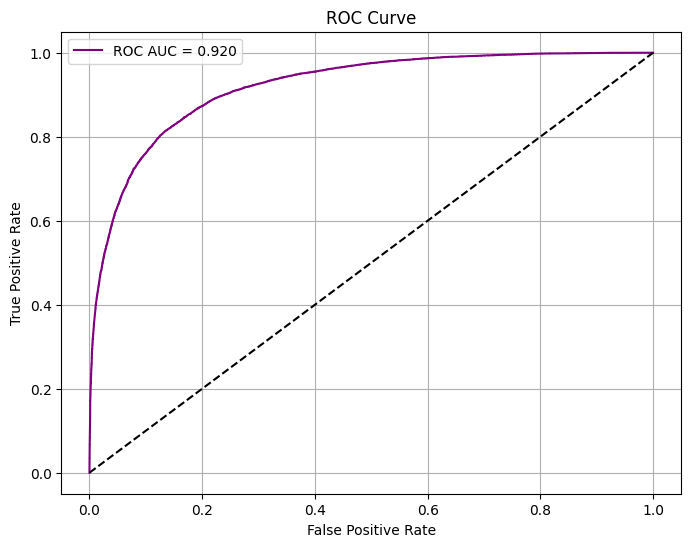

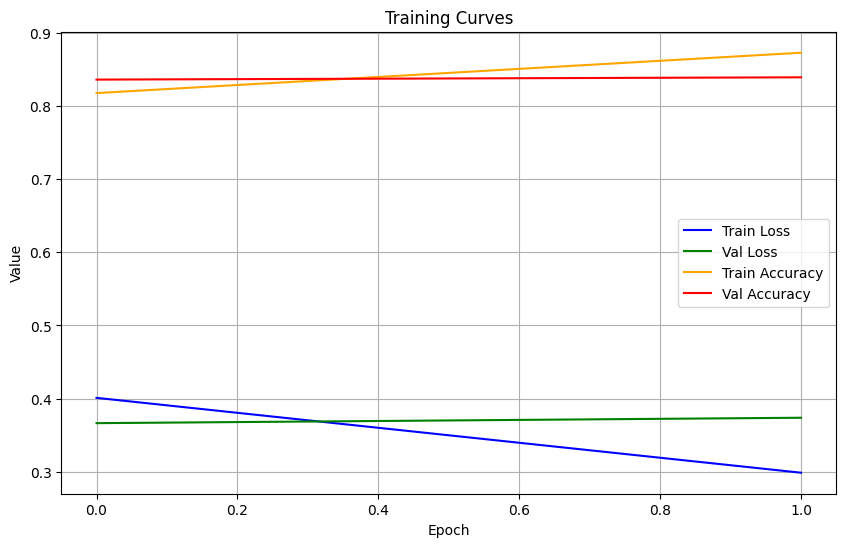

In [1]:
#Import basic libraries
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import learning_curve
from matplotlib import pyplot as plt
import emoji
from collections import Counter
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import gensim.downloader as api
from torch.optim.lr_scheduler import ReduceLROnPlateau
from gensim.models import KeyedVectors
import random
import os
from transformers import DistilBertForSequenceClassification, get_linear_schedule_with_warmup, DistilBertTokenizer
from torch.utils.data import DataLoader
import optuna

#Use a random seed to ensure reproducability
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

#Load datasets
train_dataset = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/train_dataset.csv")
validation_dataset = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/val_dataset.csv")
test_dataset = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3-distil-bert/test_dataset.csv")

#stopwords_to_remove = {"just", "im", "the", "going", "am", "are", "or", "of", "and"}

def preprocess_text(text):
    if isinstance(text, str): #Ensure input is a string
        
        text = text.lower() #Convert to lowercase

        #Remove URLs
        text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)

        #Remove hashtags and @s
        text = re.sub(r"@\w+|#\w+", "", text)

        #Remove punctuation
        text = re.sub(r"[^a-zA-Z0-9\s?!]", "", text)\

        #Correct the spelling mistakes
        text = re.sub(r"\b(luv)\b", "love", text)
        text = re.sub(r"\b(amzing)\b", "amazing", text)
        text = re.sub(r"\b(terible)\b", "terrible", text)
        text = re.sub(r"\b(excelent)\b", "excellent", text)
        text = re.sub(r"\b(perfonmence)\b", "performance", text)
        text = re.sub(r"\b(gud)\b", "good", text)
        text = re.sub(r"\b(vry)\b", "very", text)
        text = re.sub(r"\b(fntstic)\b", "fantastic", text)
        text = re.sub(r"\b(gr8)\b", "great", text)
        text = re.sub(r"\b(horrble)\b", "horrible", text)
        text = re.sub(r"\b(wanna)\b", "want to", text)
        text = re.sub(r"\b(gonna)\b", "going to", text)
        text = re.sub(r"\b(str8)\b", "straight", text)
        text = re.sub(r"\b(2night)\b", "tonight", text)
        text = re.sub(r"\b(thru)\b", "through", text)


        
        #If more than 3 characters --> Convert to 3 characters (e.g. heyyyyy --> heyyy)
        text = re.sub(r"(.)\1{2,}", r"\1", text)

        #Remove specific words (they are the most common words found in EDA for both positive and negative instances)
        
        #words = text.split()
        #text = " ".join([word for word in words if word not in stopwords_to_remove])
    
    return text

# Apply preprocessing to dataset text columns
train_dataset["Text"] = train_dataset["Text"].apply(preprocess_text)
validation_dataset["Text"] = validation_dataset["Text"].apply(preprocess_text)
test_dataset["Text"] = test_dataset["Text"].apply(preprocess_text)

#Split dataset
X_train = train_dataset["Text"]
y_train = train_dataset["Label"]
X_validation = validation_dataset["Text"]
y_validation = validation_dataset["Label"]
X_test = test_dataset["Text"]

#Split datasets into positives and negatives
positive_dataset = train_dataset[train_dataset["Label"] == 1].copy()
negative_dataset = train_dataset[train_dataset["Label"] == 0].copy()

#EDA 1 - Count how many positive and negative instances are there
class_counts = train_dataset["Label"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values, color=["lightcoral", "yellowgreen"])
plt.xticks(class_counts.index, ["Negative", "Positive"])
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Class Distribution")

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 10, str(v), ha="center", fontsize=12)
plt.show()


#EDA 2 - Sentence Length Analysis
positive_dataset["Sentence_Length"] = positive_dataset["Text"].apply(lambda x: len(str(x).split()))
negative_dataset["Sentence_Length"] = negative_dataset["Text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))

sns.histplot(positive_dataset["Sentence_Length"], bins=30, kde=True, color='green', label="Positive", alpha=0.5)
sns.histplot(negative_dataset["Sentence_Length"], bins=30, kde=True, color='red', label="Negative", alpha=0.5)

plt.title("Comparison of Sentence Lengths for Positive and Negative Sentiments")
plt.xlabel("Sentence Length (Number of Words)")
plt.ylabel("Frequency")
plt.legend()
plt.show()


train_dataset_small = train_dataset.sample(frac=1, random_state=42)
validation_dataset_small = validation_dataset.sample(frac=1, random_state=42)

# Apply preprocessing again
train_dataset_small["Text"] = train_dataset_small["Text"].apply(preprocess_text)
validation_dataset_small["Text"] = validation_dataset_small["Text"].apply(preprocess_text)

X_train = train_dataset_small["Text"]
y_train = train_dataset_small["Label"]
X_validation = validation_dataset_small["Text"]
y_validation = validation_dataset_small["Label"]

#Load pre-trained model tokenizer (vocabulary)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def encode_data(sentences, labels=None):
    input_ids = []
    attention_masks = []

    for sent in sentences:
        encoded = tokenizer.encode_plus(
            sent,
            add_special_tokens = True,
            max_length = 64,
            pad_to_max_length = True,
            return_attention_mask=True,
            truncation=True,
            return_tensors='pt'
        )
        #Add the encoded sentence to the list.
        input_ids.append(encoded['input_ids'])

        #And its attention mask (simply differentiates padding from non-padding).
        attention_masks.append(encoded['attention_mask'])

    #Convert the list into tensors
    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)

    if labels is not None:
        labels_tensor = torch.tensor(labels.values)
        return torch.utils.data.TensorDataset(input_ids, attention_masks, labels_tensor)
    else:
        return input_ids, attention_masks
    
train_dataset_tensor = encode_data(X_train, y_train)
val_dataset_tensor = encode_data(X_validation, y_validation)
test_input_ids, test_attention_masks = encode_data(X_test)

train_loader = DataLoader(train_dataset_tensor, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset_tensor, batch_size=32)

#Run with GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Load BertForSequenceClassification, the pretrained BERT model with a single
#linear classification layer on top.
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", #Use the 12-layer BERT model, with an uncased vocab.
    num_labels = 2, #The number of output labels--2 for binary classification.
                    #You can increase this for multi-class tasks.
)

#Tell pytorch to run this model on the GPU.
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)
criterion = nn.CrossEntropyLoss()

epochs = 2
total_steps = len(train_loader) * epochs
# Create the learning rate scheduler to dynamically adjust the learning rate.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0, # Default value in run_glue.py
                                            num_training_steps = total_steps)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_loss = float('inf')
early_stopping_counter = 0
early_stopping_patience = 2
best_model_state = None

for epoch in range(epochs):

    print(f"\n======== Epoch {epoch+1} / 2 ========")
    print("Training...")
    model.train()
    total_loss, correct = 0, 0
    for step, batch in enumerate(train_loader):
        input_ids, attn_mask, labels = [x.to(device) for x in batch]

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attn_mask, labels=labels)
        loss, logits = outputs.loss, outputs.logits
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()

        if step % 40 == 0 and not step == 0:
            print(f"  Batch {step} of {len(train_loader)} - Loss: {loss.item():.4f}")

    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct / len(train_loader.dataset)
    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(train_acc)

    
    print(f"  Training Loss: {avg_train_loss:.4f}")
    print(f"  Training Accuracy: {train_acc:.4f}")

    # Validation
    print("Running Validation...")

    model.eval()
    val_loss, val_correct = 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for input_ids, attn_mask, labels in val_loader:
            input_ids, attn_mask, labels = input_ids.to(device), attn_mask.to(device), labels.to(device)
            outputs = model(input_ids, attention_mask=attn_mask, labels=labels)
            loss, logits = outputs.loss, outputs.logits
            val_loss += loss.item()

            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            val_correct += (preds == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / len(val_loader.dataset)
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc)

    
    print(f"  Validation Loss: {avg_val_loss:.4f}")
    print(f"  Validation Accuracy: {val_acc:.4f}")

    print(f"Epoch {epoch+1}: Train Loss {train_losses[-1]:.4f}, Val Loss {val_losses[-1]:.4f}, Val Acc {val_acc:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            print("Early stopping")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("\nBERT Evaluation:")
print(f"Accuracy: {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1 Score: {f1:.5f}")
print(classification_report(all_labels, all_preds))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
plt.title("Confusion Matrix (BERT)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}", color="purple")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Learning Curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(val_losses, label="Val Loss", color="green")
plt.plot(train_accuracies, label="Train Accuracy", color="orange")
plt.plot(val_accuracies, label="Val Accuracy", color="red")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Curves")
plt.legend()
plt.grid(True)
plt.show()

test_dataset_tensor = torch.utils.data.TensorDataset(test_input_ids, test_attention_masks)
test_loader = DataLoader(test_dataset_tensor, batch_size=32)

model.eval()
test_preds = []

with torch.no_grad():
    for input_ids, attention_mask in test_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        probs = F.softmax(outputs.logits, dim=1)
        preds = (probs[:, 1] >= 0.5).int()
        test_preds.extend(preds.cpu().numpy())


submission_df = pd.DataFrame({"ID": test_dataset["ID"], "Label": test_preds})
submission_df.to_csv("submission.csv", index=False)